# Mutual-gradient TSO-TSO tie coordination demo

This notebook demonstrates the horizontal mutual-gradient coordinator on the existing divergent-schedule IEEE-39 multi-zone scenario from `experiments/007_TIE_COORDINATION.py`.

The comparison is between:

- `OFF`: `enable_tie_coordination=False`, i.e. each TSO zone tracks its own voltage schedule without horizontal boundary-voltage negotiation.
- `COORD`: `enable_tie_coordination=True`, where neighbouring zones exchange boundary objective gradients and negotiate an agreed tie-line voltage difference `dV_ref`.

The main performance metric used here is the steady-window mean zone RMS voltage error from the zone voltage reference, reported in mpu. A positive improvement percentage therefore means that the coordinated case has a lower RMS voltage error than the uncoordinated baseline.

## Coordination mechanism shown here

For a tie line `e=(i,j)`, the coordinator receives the two zones' local boundary-voltage objective gradients `gamma_i` and `gamma_j`. It updates the agreed voltage difference using the combined marginal

```text
G_e = kappa * gamma_i - (1 - kappa) * gamma_j
delta = -alpha * G_e - anchor * DB(dV_ref)
```

with a per-zone objective-worsening safeguard. In the runner, the two notebook sweep knobs are scaled as

```text
alpha   = tie_grad_step / (2 * g_v)
eps_obj = tie_grad_eps * g_v
```

Interpretation:

- `tie_grad_step` controls the descent step length on the joint boundary-gradient direction.
- `tie_grad_eps` controls how much local objective worsening a zone permits per coordination round. `0` allows only strictly jointly beneficial moves.
- The coordinator does not see the plant directly; it acts through cached/controller-side sensitivities and logged boundary-gradient signals.

In [1]:
from __future__ import annotations

import importlib.util
import itertools
import math
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "multi_tso_config.py").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError("Could not locate qOFO_GH project root from current working directory.")


PROJECT_ROOT = find_project_root()
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
OUT_DIR = PROJECT_ROOT / "results" / "008_tie_mutual_gradient_demo"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Numeric module name -> import via file location. This reuses the validated scenario setup.
spec = importlib.util.spec_from_file_location("tie007", EXPERIMENTS_DIR / "007_TIE_COORDINATION.py")
tie007 = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(tie007)

try:
    get_ipython().run_line_magic("matplotlib", "inline")  # type: ignore[name-defined]
except NameError:
    import matplotlib
    matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
from experiments.helpers import ContingencyEvent

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir  : {OUT_DIR}")
print(f"Default 007 schedules: {tie007.ZONE_VSET}")

Project root: Z:\Python_Projekte\qOFO_GH
Output dir  : Z:\Python_Projekte\qOFO_GH\results\008_tie_mutual_gradient_demo
Default 007 schedules: {1: 1.05, 2: 1.03, 3: 1.02}


## Sweep definition

Edit the next cell to choose the zone voltage schedule, contingency set, and sweep grid. The default shown here is a same-voltage scenario with a 400 Mvar reactive load connected in zone 2 at minute 20. Set CONTINGENCY_SPECS = [] for a no-contingency same-voltage baseline, or switch ZONE_VSET back to dict(tie007.ZONE_VSET) for the divergent-schedule case. The steady metric is averaged over the last `STEADY_MIN` minutes.

In [2]:
SCENARIO_NAME = "z1_105_z2_103_z3_104"
ZONE_VSET = {1: 1.05, 2: 1.03, 3: 1.01}
# For the original divergent-voltage scenario, use: ZONE_VSET = dict(tie007.ZONE_VSET)
LOAD_STEP_BUS = 9          # IEEE-39 bus in zone 2, close to the L14 boundary
LOAD_STEP_MVAR = 500.0
LOAD_STEP_MINUTE = 60
CONTINGENCY_SPECS = [
    dict(minute=LOAD_STEP_MINUTE, element_type="load", action="connect", bus=LOAD_STEP_BUS, p_mw=0.0, q_mvar=LOAD_STEP_MVAR),
]
# For a no-contingency same-voltage study, set CONTINGENCY_SPECS = []

def build_contingencies():
    return [ContingencyEvent(**spec) for spec in CONTINGENCY_SPECS]

def describe_contingencies():
    return "; ".join(str(spec) for spec in CONTINGENCY_SPECS) if CONTINGENCY_SPECS else "none"
HORIZON_MIN = 300
STEADY_MIN = 210

SWEEP_TAG = f"{SCENARIO_NAME}_400mvar_steps_v04"
TIE_GRAD_EPS_VALUES = [1e-3, 1e-4]
TIE_GRAD_STEP_VALUES = [0.1, 0.2]

# Set FORCE_RERUN=True to ignore an existing summary CSV.
USE_CACHE = True
FORCE_RERUN = False
MAX_RETRIES = 2

CACHE_CSV = OUT_DIR / f"mutual_gradient_sweep_{SWEEP_TAG}.csv"
print(f"Scenario: {SCENARIO_NAME}")
print(f"Zone V refs: {ZONE_VSET}")
print(f"Contingencies: {describe_contingencies()}")
print(f"Cases: 1 baseline + {len(TIE_GRAD_EPS_VALUES) * len(TIE_GRAD_STEP_VALUES)} coordinated runs")

Scenario: z1_105_z2_103_z3_104
Zone V refs: {1: 1.05, 2: 1.03, 3: 1.01}
Contingencies: {'minute': 60, 'element_type': 'load', 'action': 'connect', 'bus': 9, 'p_mw': 0.0, 'q_mvar': 500.0}
Cases: 1 baseline + 4 coordinated runs


In [3]:
RUN_LOGS: dict[object, tuple[list, object]] = {}


def case_key(enable_tie_coordination: bool, tie_grad_eps: float | None, tie_grad_step: float | None) -> object:
    if not enable_tie_coordination:
        return (SCENARIO_NAME, "OFF")
    return (SCENARIO_NAME, float(tie_grad_eps), float(tie_grad_step))


def finite_mean(values) -> float:
    arr = np.asarray(list(values), dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(arr.mean()) if arr.size else float("nan")


def steady_records(log, cfg):
    cutoff_s = cfg.n_total_s - STEADY_MIN * 60.0
    return [rec for rec in log if rec.time_s >= cutoff_s]


def make_config(enable_tie_coordination: bool, tie_grad_eps: float | None = None, tie_grad_step: float | None = None):
    cfg = tie007._base_config(live=False)
    cfg.n_total_s = 60.0 * HORIZON_MIN
    cfg.verbose = 0
    cfg.run_stability_analysis = False
    cfg.zone_v_setpoints_pu = dict(ZONE_VSET)
    cfg.contingencies = build_contingencies()

    if enable_tie_coordination:
        for key, value in tie007.TIE_KW.items():
            setattr(cfg, key, value)
        cfg.tie_grad_eps = float(tie_grad_eps)
        cfg.tie_grad_step = float(tie_grad_step)
    else:
        cfg.enable_tie_coordination = False

    return cfg


def summarize_case(log, cfg, label: str, enable_tie_coordination: bool, tie_grad_eps: float | None, tie_grad_step: float | None) -> dict:
    win = steady_records(log, cfg)
    zones = sorted({z for rec in win for z in rec.zone_v_rms_err_pu})
    ties = sorted({tie for rec in win for tie in rec.tie_q_mvar})

    zone_rms_pu = {
        f"v_rms_z{z}_mpu": 1e3 * finite_mean(rec.zone_v_rms_err_pu.get(z, np.nan) for rec in win)
        for z in zones
    }
    mean_zone_rms_mpu = finite_mean(zone_rms_pu.values())

    sum_abs_tie_q_mvar = sum(
        finite_mean(abs(rec.tie_q_mvar.get(tie, np.nan)) for rec in win)
        for tie in ties
    )

    row = {
        "case": label,
        "scenario": SCENARIO_NAME,
        "zone_vset": str(ZONE_VSET),
        "contingencies": describe_contingencies(),
        "n_contingencies": len(CONTINGENCY_SPECS),
        "enable_tie_coordination": bool(enable_tie_coordination),
        "tie_grad_eps": np.nan if tie_grad_eps is None else float(tie_grad_eps),
        "tie_grad_step": np.nan if tie_grad_step is None else float(tie_grad_step),
        "v_rms_mpu": mean_zone_rms_mpu,
        "sum_abs_tie_q_mvar": float(sum_abs_tie_q_mvar),
        "mean_abs_dvref_mpu": 1e3 * finite_mean(abs(v) for rec in win for v in rec.tie_dvref.values()),
        "mean_abs_dv_realized_mpu": 1e3 * finite_mean(abs(v) for rec in win for v in rec.tie_dv_realized.values()),
        "mean_abs_grad_combined": finite_mean(abs(v) for rec in win for v in rec.tie_grad_combined.values()),
        "n_records": len(log),
        "n_steady_records": len(win),
    }
    row.update(zone_rms_pu)
    return row


def run_case(label: str, enable_tie_coordination: bool, tie_grad_eps: float | None = None, tie_grad_step: float | None = None) -> dict:
    cfg = make_config(enable_tie_coordination, tie_grad_eps, tie_grad_step)
    t0 = time.perf_counter()
    log = tie007.run_multi_tso_dso(cfg)
    runtime_s = time.perf_counter() - t0
    RUN_LOGS[case_key(enable_tie_coordination, tie_grad_eps, tie_grad_step)] = (log, cfg)

    row = summarize_case(log, cfg, label, enable_tie_coordination, tie_grad_eps, tie_grad_step)
    row["runtime_s"] = runtime_s
    return row


def run_case_resilient(label: str, enable_tie_coordination: bool, tie_grad_eps: float | None = None, tie_grad_step: float | None = None) -> dict:
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            print(f"Running {label} (attempt {attempt}/{MAX_RETRIES})")
            return run_case(label, enable_tie_coordination, tie_grad_eps, tie_grad_step)
        except Exception as exc:  # noqa: BLE001 - notebook diagnostics should expose full failures
            last_error = exc
            print(f"  failed: {type(exc).__name__}: {exc}")
    raise RuntimeError(f"Case {label} failed after {MAX_RETRIES} attempts") from last_error

In [4]:
if USE_CACHE and CACHE_CSV.exists() and not FORCE_RERUN:
    results = pd.read_csv(CACHE_CSV)
    print(f"Loaded cached sweep: {CACHE_CSV}")
else:
    rows = []

    rows.append(run_case_resilient("OFF", False))
    pd.DataFrame(rows).to_csv(CACHE_CSV, index=False)

    for eps, step in itertools.product(TIE_GRAD_EPS_VALUES, TIE_GRAD_STEP_VALUES):
        label = f"eps={eps:g}, step={step:g}"
        rows.append(run_case_resilient(label, True, eps, step))
        pd.DataFrame(rows).to_csv(CACHE_CSV, index=False)

    results = pd.DataFrame(rows)
    print(f"Saved sweep summary: {CACHE_CSV}")

coord_mask = results["enable_tie_coordination"].astype(str).str.lower().isin(["true", "1"])
baseline = results.loc[~coord_mask].iloc[0]
coordinated = results.loc[coord_mask].copy()

coordinated["v_rms_delta_mpu"] = coordinated["v_rms_mpu"] - baseline["v_rms_mpu"]
coordinated["v_rms_improvement_pct"] = 100.0 * (baseline["v_rms_mpu"] - coordinated["v_rms_mpu"]) / baseline["v_rms_mpu"]
coordinated["tie_q_delta_mvar"] = coordinated["sum_abs_tie_q_mvar"] - baseline["sum_abs_tie_q_mvar"]
coordinated["tie_q_reduction_pct"] = 100.0 * (baseline["sum_abs_tie_q_mvar"] - coordinated["sum_abs_tie_q_mvar"]) / baseline["sum_abs_tie_q_mvar"]

print("Baseline OFF steady metrics")
display(baseline[["v_rms_mpu", "sum_abs_tie_q_mvar", "n_records", "n_steady_records"]].to_frame("OFF"))

display(
    coordinated.sort_values(["tie_grad_eps", "tie_grad_step"])[[
        "tie_grad_eps", "tie_grad_step", "v_rms_mpu", "v_rms_delta_mpu",
        "v_rms_improvement_pct", "sum_abs_tie_q_mvar", "tie_q_reduction_pct",
        "mean_abs_dvref_mpu", "mean_abs_grad_combined",
    ]].style.format({
        "tie_grad_eps": "{:.0e}",
        "tie_grad_step": "{:.2f}",
        "v_rms_mpu": "{:.2f}",
        "v_rms_delta_mpu": "{:+.2f}",
        "v_rms_improvement_pct": "{:+.1f}%",
        "sum_abs_tie_q_mvar": "{:.1f}",
        "tie_q_reduction_pct": "{:+.1f}%",
        "mean_abs_dvref_mpu": "{:.2f}",
        "mean_abs_grad_combined": "{:.2e}",
    })
)

Running OFF (attempt 1/2)

  Zonal Generator Dispatch (per-zone residual-load balancing)
  Per-gen P cap: alpha * sn_mva   with alpha = 0.85
  Zone 1: 14 loads, 1 sgens, 3 gens  ->  P_gen range [111.5, 1300.7] MW, mean 476.1 MW
          spill_in : mean   55.4 MW, peak  185.1 MW   (zone exports to cover other zones)
          spill_out: mean    0.0 MW, peak    0.0 MW   (unmet residual absorbed by slack)
  Zone 2: 69 loads, 31 sgens, 1 gens  ->  P_gen range [570.1, 680.0] MW, mean 651.7 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   39.3 MW, peak  131.6 MW   (unmet residual absorbed by slack)
  Zone 3: 31 loads, 12 sgens, 2 gens  ->  P_gen range [539.4, 680.0] MW, mean 627.3 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   16.1 MW, peak   53.5 MW   (unmet residual absorbed by slack)
-------------------------------------------------------------

C:\Users\Manuel Schwenke\AppData\Local\Temp\ipykernel_36188\1515841838.py:80: RuntimeWarning: enable_tie_coordination is True but g_z_q_tie <= 0; the Q_tie soft cap will be inert (free slack). Set g_z_q_tie > 0 to enforce the tie_q_band_mvar band.
  log = tie007.run_multi_tso_dso(cfg)



  Zonal Generator Dispatch (per-zone residual-load balancing)
  Per-gen P cap: alpha * sn_mva   with alpha = 0.85
  Zone 1: 14 loads, 1 sgens, 3 gens  ->  P_gen range [111.5, 1300.7] MW, mean 476.1 MW
          spill_in : mean   55.4 MW, peak  185.1 MW   (zone exports to cover other zones)
          spill_out: mean    0.0 MW, peak    0.0 MW   (unmet residual absorbed by slack)
  Zone 2: 69 loads, 31 sgens, 1 gens  ->  P_gen range [570.1, 680.0] MW, mean 651.7 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   39.3 MW, peak  131.6 MW   (unmet residual absorbed by slack)
  Zone 3: 31 loads, 12 sgens, 2 gens  ->  P_gen range [539.4, 680.0] MW, mean 627.3 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   16.1 MW, peak   53.5 MW   (unmet residual absorbed by slack)
------------------------------------------------------------------------
  System gen d

C:\Users\Manuel Schwenke\AppData\Local\Temp\ipykernel_36188\1515841838.py:80: RuntimeWarning: enable_tie_coordination is True but g_z_q_tie <= 0; the Q_tie soft cap will be inert (free slack). Set g_z_q_tie > 0 to enforce the tie_q_band_mvar band.
  log = tie007.run_multi_tso_dso(cfg)



  Zonal Generator Dispatch (per-zone residual-load balancing)
  Per-gen P cap: alpha * sn_mva   with alpha = 0.85
  Zone 1: 14 loads, 1 sgens, 3 gens  ->  P_gen range [111.5, 1300.7] MW, mean 476.1 MW
          spill_in : mean   55.4 MW, peak  185.1 MW   (zone exports to cover other zones)
          spill_out: mean    0.0 MW, peak    0.0 MW   (unmet residual absorbed by slack)
  Zone 2: 69 loads, 31 sgens, 1 gens  ->  P_gen range [570.1, 680.0] MW, mean 651.7 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   39.3 MW, peak  131.6 MW   (unmet residual absorbed by slack)
  Zone 3: 31 loads, 12 sgens, 2 gens  ->  P_gen range [539.4, 680.0] MW, mean 627.3 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   16.1 MW, peak   53.5 MW   (unmet residual absorbed by slack)
------------------------------------------------------------------------
  System gen d

...


  Zonal Generator Dispatch (per-zone residual-load balancing)
  Per-gen P cap: alpha * sn_mva   with alpha = 0.85
  Zone 1: 14 loads, 1 sgens, 3 gens  ->  P_gen range [111.5, 1300.7] MW, mean 476.1 MW
          spill_in : mean   55.4 MW, peak  185.1 MW   (zone exports to cover other zones)
          spill_out: mean    0.0 MW, peak    0.0 MW   (unmet residual absorbed by slack)
  Zone 2: 69 loads, 31 sgens, 1 gens  ->  P_gen range [570.1, 680.0] MW, mean 651.7 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   39.3 MW, peak  131.6 MW   (unmet residual absorbed by slack)
  Zone 3: 31 loads, 12 sgens, 2 gens  ->  P_gen range [539.4, 680.0] MW, mean 627.3 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   16.1 MW, peak   53.5 MW   (unmet residual absorbed by slack)
------------------------------------------------------------------------
  System gen d

C:\Users\Manuel Schwenke\AppData\Local\Temp\ipykernel_36188\1515841838.py:80: RuntimeWarning: enable_tie_coordination is True but g_z_q_tie <= 0; the Q_tie soft cap will be inert (free slack). Set g_z_q_tie > 0 to enforce the tie_q_band_mvar band.
  log = tie007.run_multi_tso_dso(cfg)



  Zonal Generator Dispatch (per-zone residual-load balancing)
  Per-gen P cap: alpha * sn_mva   with alpha = 0.85
  Zone 1: 14 loads, 1 sgens, 3 gens  ->  P_gen range [111.5, 1300.7] MW, mean 476.1 MW
          spill_in : mean   55.4 MW, peak  185.1 MW   (zone exports to cover other zones)
          spill_out: mean    0.0 MW, peak    0.0 MW   (unmet residual absorbed by slack)
  Zone 2: 69 loads, 31 sgens, 1 gens  ->  P_gen range [570.1, 680.0] MW, mean 651.7 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   39.3 MW, peak  131.6 MW   (unmet residual absorbed by slack)
  Zone 3: 31 loads, 12 sgens, 2 gens  ->  P_gen range [539.4, 680.0] MW, mean 627.3 MW
          spill_in : mean    0.0 MW, peak    0.0 MW   (zone exports to cover other zones)
          spill_out: mean   16.1 MW, peak   53.5 MW   (unmet residual absorbed by slack)
------------------------------------------------------------------------
  System gen d

,OFF
v_rms_mpu,18.120253
sum_abs_tie_q_mvar,310.639596
n_records,900
n_steady_records,631


,tie_grad_eps,tie_grad_step,v_rms_mpu,v_rms_delta_mpu,v_rms_improvement_pct,sum_abs_tie_q_mvar,tie_q_reduction_pct,mean_abs_dvref_mpu,mean_abs_grad_combined
3,1e-04,0.10,14.83,-3.29,+18.1%,247.5,+20.3%,3.17,1.34e+05
4,1e-04,0.20,14.90,-3.22,+17.8%,250.7,+19.3%,5.24,1.53e+05
1,1e-03,0.10,14.85,-3.27,+18.1%,247.8,+20.2%,3.06,1.26e+05
2,1e-03,0.20,14.90,-3.22,+17.8%,251.0,+19.2%,4.65,1.31e+05


In [5]:
best = coordinated.sort_values(["v_rms_mpu", "sum_abs_tie_q_mvar"]).head(10)
print("Best coordinated settings by steady-window voltage RMS error")
display(
    best[[
        "tie_grad_eps", "tie_grad_step", "v_rms_mpu", "v_rms_improvement_pct",
        "sum_abs_tie_q_mvar", "tie_q_reduction_pct", "mean_abs_dvref_mpu",
    ]].style.format({
        "tie_grad_eps": "{:.0e}",
        "tie_grad_step": "{:.2f}",
        "v_rms_mpu": "{:.2f}",
        "v_rms_improvement_pct": "{:+.1f}%",
        "sum_abs_tie_q_mvar": "{:.1f}",
        "tie_q_reduction_pct": "{:+.1f}%",
        "mean_abs_dvref_mpu": "{:.2f}",
    })
)

Best coordinated settings by steady-window voltage RMS error


,tie_grad_eps,tie_grad_step,v_rms_mpu,v_rms_improvement_pct,sum_abs_tie_q_mvar,tie_q_reduction_pct,mean_abs_dvref_mpu
3,1e-04,0.10,14.83,+18.1%,247.5,+20.3%,3.17
1,1e-03,0.10,14.85,+18.1%,247.8,+20.2%,3.06
4,1e-04,0.20,14.90,+17.8%,250.7,+19.3%,5.24
2,1e-03,0.20,14.90,+17.8%,251.0,+19.2%,4.65


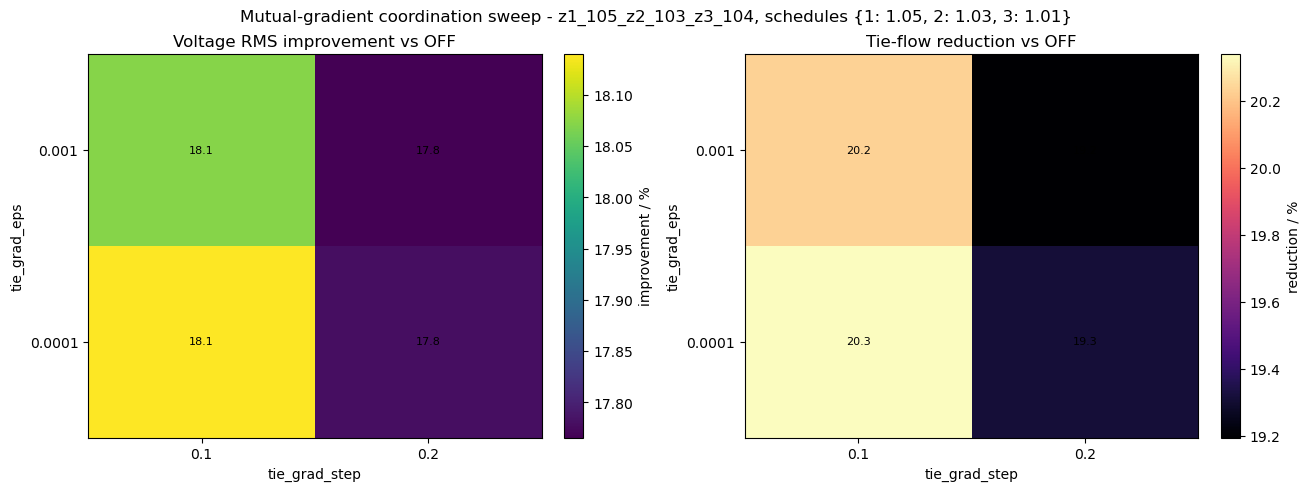

In [6]:
def plot_heatmap(ax, data: pd.DataFrame, metric: str, title: str, cbar_label: str, cmap: str):
    pivot = data.pivot(index="tie_grad_eps", columns="tie_grad_step", values=metric).sort_index().sort_index(axis=1)
    image = ax.imshow(pivot.values, origin="lower", aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{x:g}" for x in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f"{x:g}" for x in pivot.index])
    ax.set_xlabel("tie_grad_step")
    ax.set_ylabel("tie_grad_eps")
    ax.set_title(title)
    cbar = plt.colorbar(image, ax=ax)
    cbar.set_label(cbar_label)

    for row in range(pivot.shape[0]):
        for col in range(pivot.shape[1]):
            value = pivot.values[row, col]
            if np.isfinite(value):
                ax.text(col, row, f"{value:.1f}", ha="center", va="center", fontsize=8, color="black")


fig, axs = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
plot_heatmap(axs[0], coordinated, "v_rms_improvement_pct", "Voltage RMS improvement vs OFF", "improvement / %", "viridis")
plot_heatmap(axs[1], coordinated, "tie_q_reduction_pct", "Tie-flow reduction vs OFF", "reduction / %", "magma")
fig.suptitle(f"Mutual-gradient coordination sweep - {SCENARIO_NAME}, schedules {ZONE_VSET}")
fig.savefig(OUT_DIR / f"mutual_gradient_heatmaps_{SWEEP_TAG}.png", dpi=150, bbox_inches="tight")
plt.show()

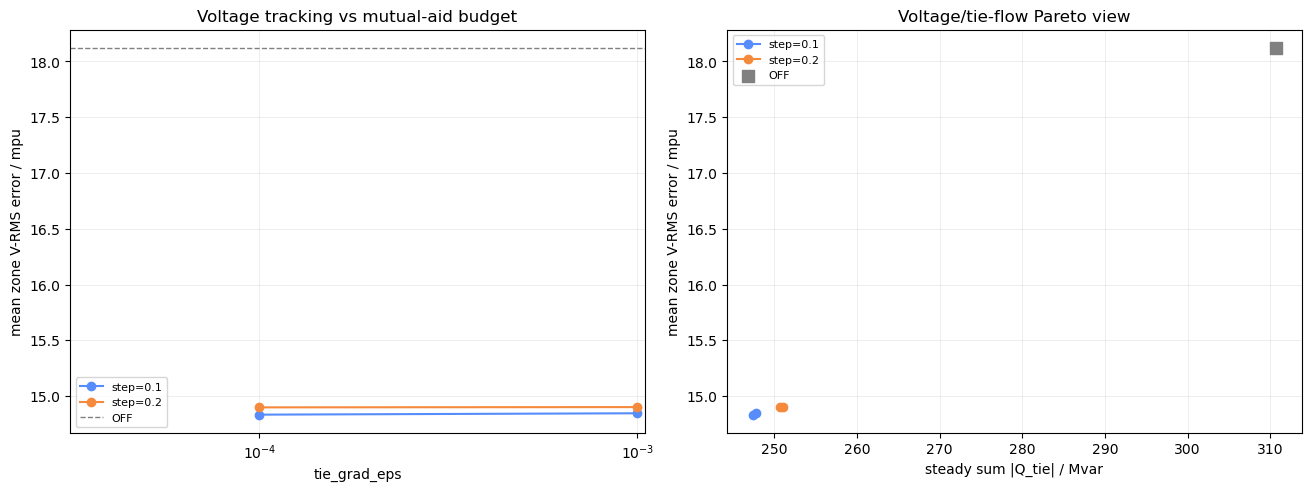

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

for step, df_step in coordinated.sort_values("tie_grad_eps").groupby("tie_grad_step"):
    axs[0].plot(df_step["tie_grad_eps"], df_step["v_rms_mpu"], marker="o", label=f"step={step:g}")
    axs[1].plot(df_step["sum_abs_tie_q_mvar"], df_step["v_rms_mpu"], marker="o", label=f"step={step:g}")

axs[0].axhline(baseline["v_rms_mpu"], color="0.5", linestyle="--", linewidth=1.0, label="OFF")
axs[0].set_xscale("symlog", linthresh=1e-4)
axs[0].set_xlabel("tie_grad_eps")
axs[0].set_ylabel("mean zone V-RMS error / mpu")
axs[0].set_title("Voltage tracking vs mutual-aid budget")
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=8)

axs[1].scatter([baseline["sum_abs_tie_q_mvar"]], [baseline["v_rms_mpu"]], color="0.5", marker="s", s=80, label="OFF", zorder=4)
axs[1].set_xlabel("steady sum |Q_tie| / Mvar")
axs[1].set_ylabel("mean zone V-RMS error / mpu")
axs[1].set_title("Voltage/tie-flow Pareto view")
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=8)

fig.savefig(OUT_DIR / f"mutual_gradient_pareto_{SWEEP_TAG}.png", dpi=150, bbox_inches="tight")
plt.show()

## Diagnostic trace for one coordinated setting

The heatmaps show the parameter surface. The next cell shows the mechanism for one selected operating point: voltage tracking, total tie exchange, the combined boundary-gradient signal, and the negotiated `dV_ref`. If the sweep was loaded from CSV, this cell reruns only the OFF case and the selected coordinated case so that the full logs are available.

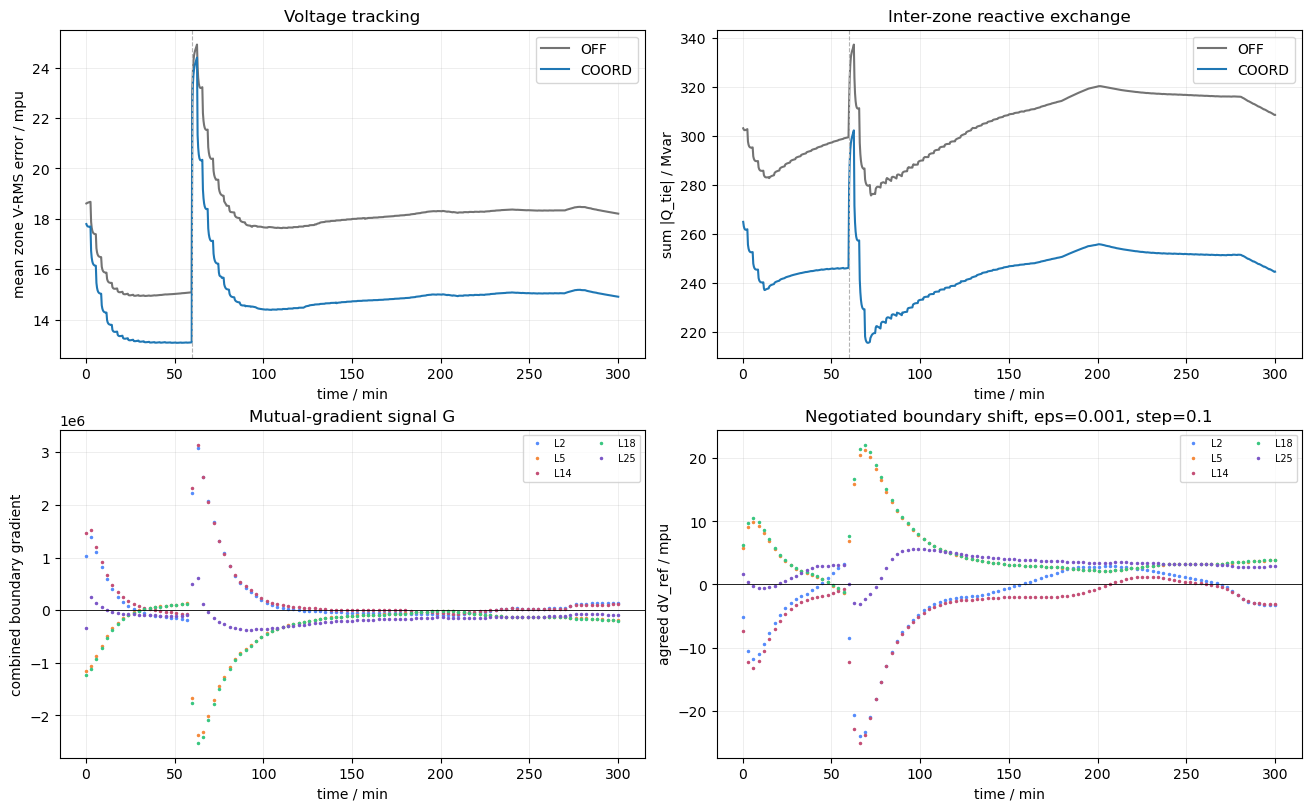

In [8]:
SELECT_EPS = 1e-3
SELECT_STEP = 0.1


def get_log(enable_tie_coordination: bool, tie_grad_eps: float | None = None, tie_grad_step: float | None = None):
    key = case_key(enable_tie_coordination, tie_grad_eps, tie_grad_step)
    if key not in RUN_LOGS:
        label = "OFF" if not enable_tie_coordination else f"diagnostic eps={tie_grad_eps:g}, step={tie_grad_step:g}"
        run_case_resilient(label, enable_tie_coordination, tie_grad_eps, tie_grad_step)
    return RUN_LOGS[key]


off_log, off_cfg = get_log(False)
coord_log, coord_cfg = get_log(True, SELECT_EPS, SELECT_STEP)


def time_min(log):
    return np.asarray([rec.time_s / 60.0 for rec in log], dtype=float)


def mean_zone_v_rms_series(log):
    return np.asarray([1e3 * finite_mean(rec.zone_v_rms_err_pu.values()) for rec in log], dtype=float)


def sum_abs_tie_q_series(log):
    ties = sorted({tie for rec in log for tie in rec.tie_q_mvar})
    return np.asarray([sum(abs(rec.tie_q_mvar.get(tie, np.nan)) for tie in ties) for rec in log], dtype=float)


coord_ties = sorted({tie for rec in coord_log for tie in rec.tie_dvref})

fig, axs = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

axs[0, 0].plot(time_min(off_log), mean_zone_v_rms_series(off_log), color="0.45", label="OFF")
axs[0, 0].plot(time_min(coord_log), mean_zone_v_rms_series(coord_log), color="tab:blue", label="COORD")
axs[0, 0].set_xlabel("time / min")
axs[0, 0].set_ylabel("mean zone V-RMS error / mpu")
axs[0, 0].set_title("Voltage tracking")
axs[0, 0].grid(alpha=0.3)
axs[0, 0].legend()

axs[0, 1].plot(time_min(off_log), sum_abs_tie_q_series(off_log), color="0.45", label="OFF")
axs[0, 1].plot(time_min(coord_log), sum_abs_tie_q_series(coord_log), color="tab:blue", label="COORD")
axs[0, 1].set_xlabel("time / min")
axs[0, 1].set_ylabel("sum |Q_tie| / Mvar")
axs[0, 1].set_title("Inter-zone reactive exchange")
axs[0, 1].grid(alpha=0.3)
axs[0, 1].legend()
for spec in CONTINGENCY_SPECS:
    minute = spec.get("minute")
    if minute is not None:
        axs[0, 0].axvline(float(minute), color="0.7", linestyle="--", linewidth=0.8)
        axs[0, 1].axvline(float(minute), color="0.7", linestyle="--", linewidth=0.8)

for tie in coord_ties:
    axs[1, 0].plot(time_min(coord_log), [rec.tie_grad_combined.get(tie, np.nan) for rec in coord_log], marker=".", markersize=3, linestyle="None", label=f"L{tie}")
axs[1, 0].axhline(0.0, color="k", linewidth=0.6)
axs[1, 0].set_xlabel("time / min")
axs[1, 0].set_ylabel("combined boundary gradient")
axs[1, 0].set_title("Mutual-gradient signal G")
axs[1, 0].grid(alpha=0.3)
axs[1, 0].legend(fontsize=7, ncol=2)

for tie in coord_ties:
    axs[1, 1].plot(time_min(coord_log), [1e3 * rec.tie_dvref.get(tie, np.nan) for rec in coord_log], marker=".", markersize=3, linestyle="None", label=f"L{tie}")
axs[1, 1].axhline(0.0, color="k", linewidth=0.6)
axs[1, 1].set_xlabel("time / min")
axs[1, 1].set_ylabel("agreed dV_ref / mpu")
axs[1, 1].set_title(f"Negotiated boundary shift, eps={SELECT_EPS:g}, step={SELECT_STEP:g}")
axs[1, 1].grid(alpha=0.3)
axs[1, 1].legend(fontsize=7, ncol=2)

fig.savefig(OUT_DIR / f"mutual_gradient_diagnostic_trace_{SWEEP_TAG}.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation checklist

When discussing a completed run, report:

- Assumptions: IEEE-39 multi-zone case, divergent zone voltage schedules, cached sensitivity/controller model, no plant visibility inside the coordinator, steady-window metric.
- Constraints: voltage objective, power-flow feasibility, `dV_ref` clipping, and the per-zone objective-worsening safeguard controlled by `tie_grad_eps`.
- Actuators: the CIGRE multi-zone configuration's TSO actuators, including generator AVR setpoints, OLTCs, TS-connected DER/PCC controls, and any enabled shunt devices.
- Controlled outputs: zone voltage tracking and inter-zone tie reactive exchange; the notebook's main plotted objective is mean zone V-RMS error from reference.
- Result pattern: identify whether coordination gives a lower V-RMS error than OFF, whether tie exchange is also reduced, and whether the effect saturates or becomes sensitive as `tie_grad_step` grows.

Open questions to keep separate from established results: whether the same tuning remains favourable under non-divergent schedules, contingencies, stronger reserve weights, or future asymmetric aid mechanisms.